# Test model tren `datatest/` (chi lop Vision - KHONG qua chatbot)

Notebook nay chay thang detector (YOLOv8, bbox) + classifier (6 lop) tren tung anh trong `datatest/`, **khong** goi qua `5_chatbot_dental_agent.py` (khong hoi trieu chung, khong dung OpenAI).

Voi moi thu muc con trong `datatest/` (ten thu muc = nhan that cua benh):
- Tieu de phia tren (suptitle) = ten thu muc (nhan that)
- Moi anh duoc ve lai bbox detector tim duoc (neu co)
- Chu thich phia duoi moi anh = ket qua model du doan (mau xanh = du doan dung voi nhan that, do = sai, cam = khong phat hien gi)

In [25]:
import sys
from pathlib import Path
from importlib import import_module

import cv2
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\lab-hackathon")
sys.path.insert(0, str(BASE_DIR))

prep = import_module("1_dental_preprocess")
detect = import_module("2_detect_dental_conditions")

DATATEST_DIR = BASE_DIR / "datatest"

## Nap model 1 lan duy nhat

(khong nap lai cho moi anh - rat lang phi khi test ca folder)

In [26]:
config = detect.load_config()
detector = detect.DentalDetector(config["detector_weights"], config.get("detector_conf_threshold", 0.35))
classifier = detect.DentalClassifier(config["classifier_checkpoint"])
print("Da nap xong detector + classifier.")
print("detector_weights:", config["detector_weights"])
print("classifier_checkpoint:", config["classifier_checkpoint"])

Da nap xong detector + classifier.
detector_weights: C:\lab-hackathon\artifacts\detector_runs\weights\best.pt
classifier_checkpoint: C:\lab-hackathon\artifacts\classifier_best.pt


In [27]:
BOX_COLOR_BGR = (0, 255, 0)  # xanh la, ve len anh (BGR - OpenCV)


def predict_and_annotate(image_path: Path):
    """Chay pipeline detector+classifier tren 1 anh, ve bbox detector tim duoc
    len anh, tra ve (anh_RGB_de_hien_thi, chu_thich, danh_sach_flagged|None).
    flagged = None nghia la anh khong dat chat luong toi thieu."""
    image_bgr = prep.load_image(image_path)
    quality = prep.check_image_quality(image_bgr)
    if not quality.is_acceptable:
        display_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        caption = "Khong dat chat luong: " + "; ".join(quality.issues)
        return display_rgb, caption, None

    findings = detect._run_pipeline_with_models(image_path, detector, classifier, config)

    annotated = image_bgr.copy()
    for det in findings.detections:
        x1, y1, x2, y2 = [int(v) for v in det.bbox_xyxy]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), BOX_COLOR_BGR, 3)
        label_text = f"{det.label} {det.confidence:.0%}"
        cv2.putText(
            annotated, label_text, (x1, max(y1 - 10, 15)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, BOX_COLOR_BGR, 2,
        )

    flagged = findings.flagged()
    if flagged:
        caption = " | ".join(f"{c.label}:{c.confidence:.0%}" for c in flagged)
    else:
        caption = "(khong phat hien gi)"

    display_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    return display_rgb, caption, flagged

In [28]:
N_COLS = 4  # so anh moi hang trong luoi hien thi


def show_folder(folder: Path):
    """Ve 1 luoi anh cho 1 thu muc nhan: tieu de tren cung = ten thu muc (nhan
    that), moi anh co bbox model tim duoc + chu thich du doan ben duoi."""
    label = folder.name
    image_paths = sorted(p for p in folder.iterdir() if p.suffix in prep.IMAGE_EXTS)
    if not image_paths:
        print(f"[{label}] khong co anh, bo qua.")
        return

    n = len(image_paths)
    n_cols = min(N_COLS, n)
    n_rows = -(-n // n_cols)  # ceil division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.8 * n_rows), squeeze=False)
    fig.suptitle(f"Nhan (ten thu muc): {label}", fontsize=16, fontweight="bold")
    axes = axes.flatten()

    for ax, img_path in zip(axes, image_paths):
        try:
            display_rgb, caption, flagged = predict_and_annotate(img_path)
        except Exception as exc:
            ax.axis("off")
            ax.set_title(img_path.name, fontsize=9)
            ax.text(0.5, 0.5, f"LOI: {exc}", transform=ax.transAxes, ha="center", va="center", color="red", wrap=True)
            continue

        top1 = flagged[0].label if flagged else None
        if flagged is None:
            caption_color = "orange"
        elif top1 is None:
            caption_color = "orange"
        else:
            caption_color = "green" if top1 == label else "red"

        ax.imshow(display_rgb)
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=9)
        ax.text(
            0.5, -0.08, caption, transform=ax.transAxes,
            ha="center", va="top", fontsize=10, color=caption_color, wrap=True,
        )

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Chay tren toan bo `datatest/`

Moi thu muc con = 1 luoi anh rieng.

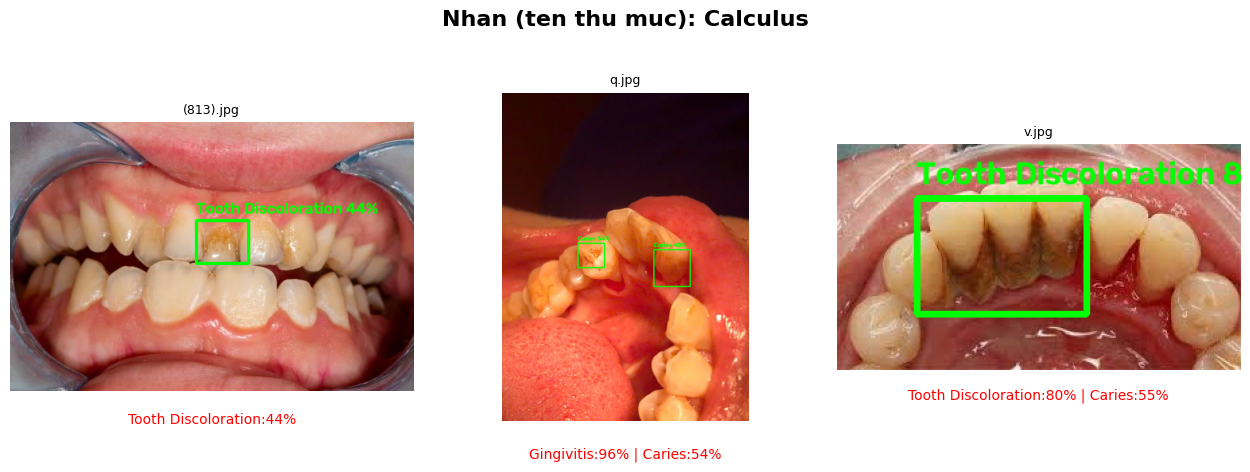

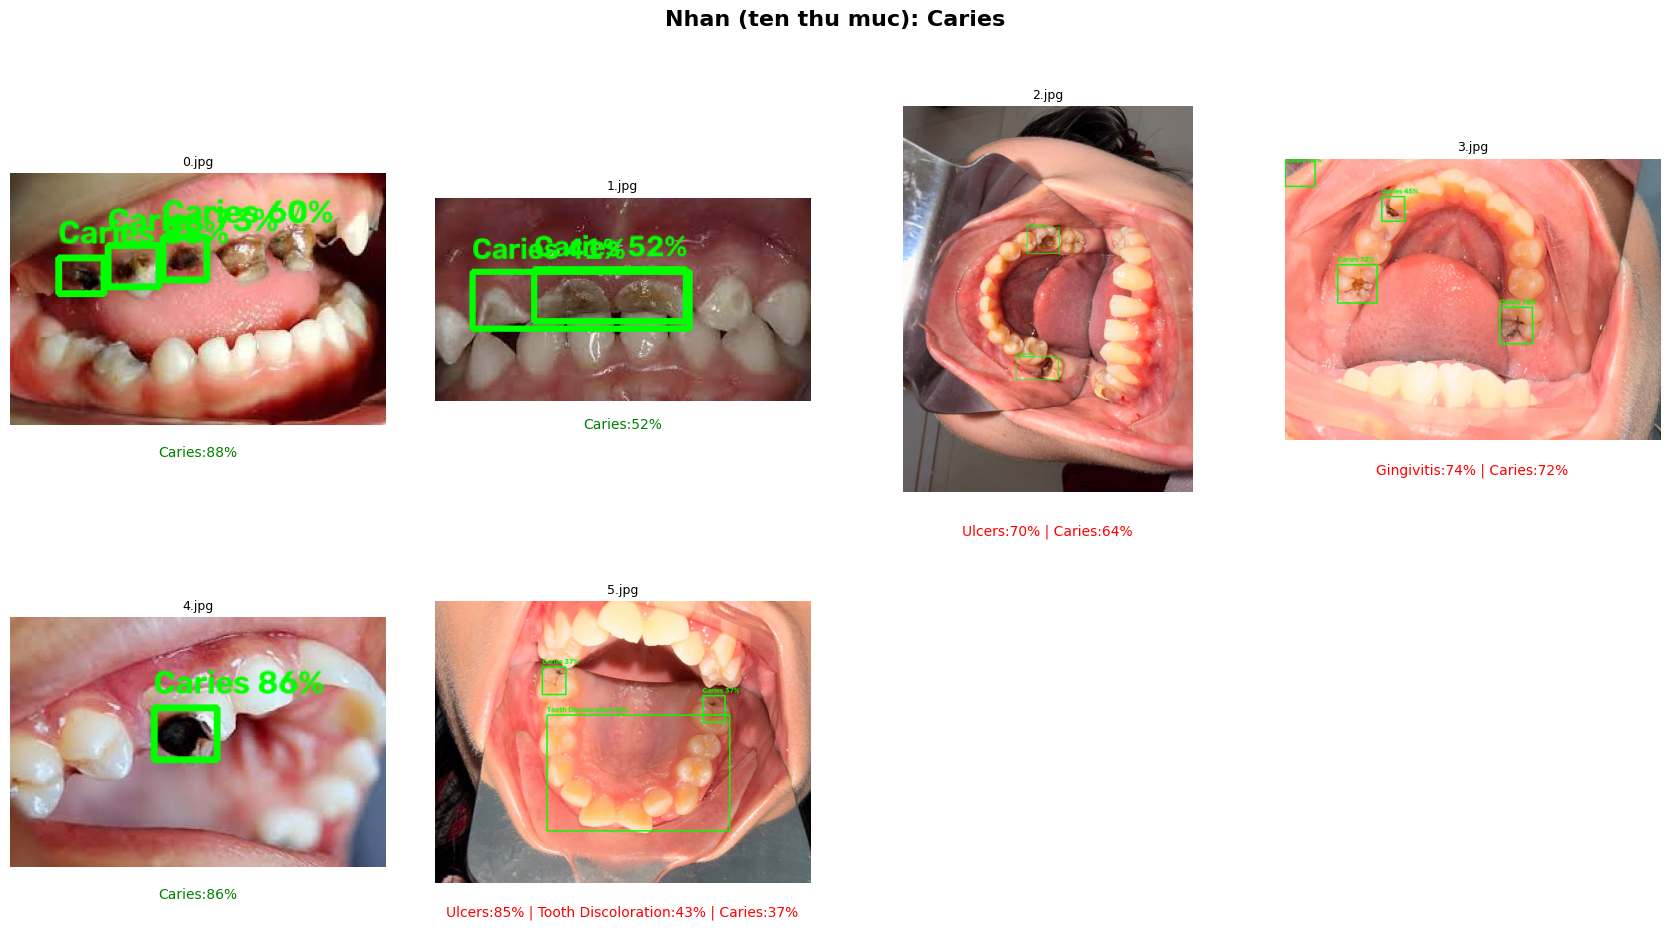

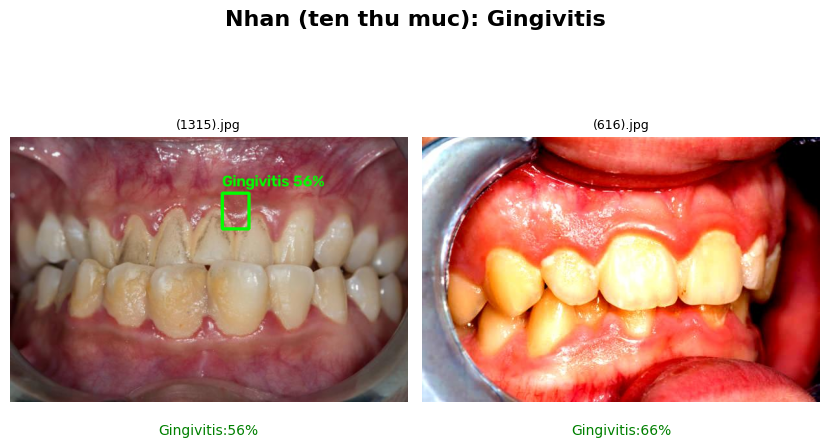

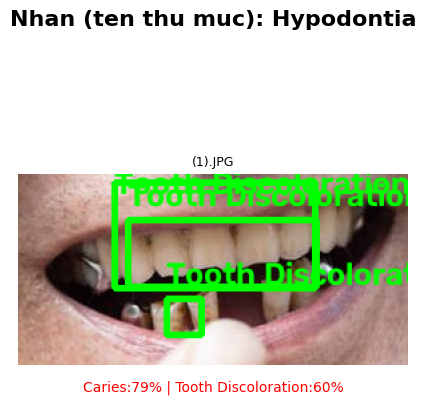

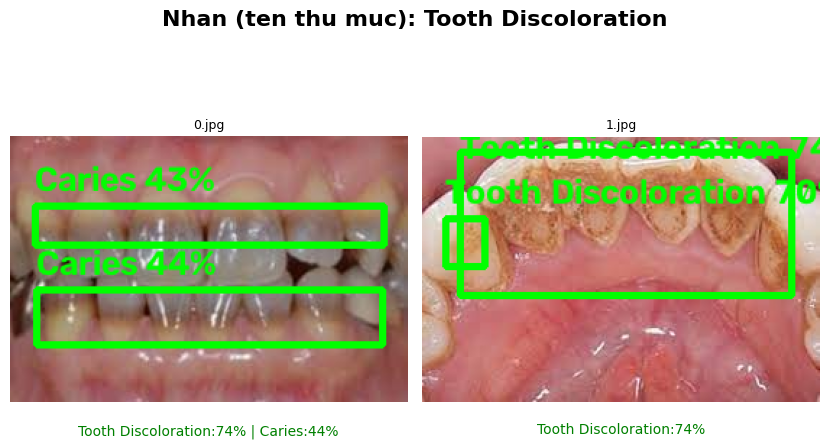

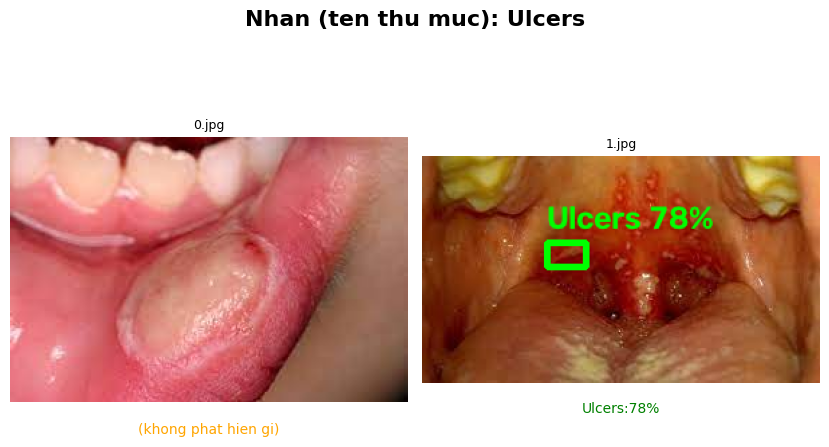

In [29]:
for folder in sorted(DATATEST_DIR.iterdir()):
    if folder.is_dir():
        show_folder(folder)

## (Tuy chon) bang tong ket accuracy theo tung lop

In [30]:
detect.run_batch(DATATEST_DIR, config=config)

(813).jpg                      | ky_vong=Calculus               | phat_hien: Tooth Discoloration:44% | SAI
q.jpg                          | ky_vong=Calculus               | phat_hien: Gingivitis:96%, Caries:54% | SAI
v.jpg                          | ky_vong=Calculus               | phat_hien: Tooth Discoloration:80%, Caries:55% | SAI
0.jpg                          | ky_vong=Caries                 | phat_hien: Caries:88% | OK
1.jpg                          | ky_vong=Caries                 | phat_hien: Caries:52% | OK
2.jpg                          | ky_vong=Caries                 | phat_hien: Ulcers:70%, Caries:64% | dung-nhung-khong-top1
3.jpg                          | ky_vong=Caries                 | phat_hien: Gingivitis:74%, Caries:72% | dung-nhung-khong-top1
4.jpg                          | ky_vong=Caries                 | phat_hien: Caries:86% | OK
5.jpg                          | ky_vong=Caries                 | phat_hien: Ulcers:85%, Tooth Discoloration:43%, Caries:37% | dung-n